In [14]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers import Adam
from scipy.io import loadmat
import matplotlib.pyplot as plt

In [15]:
# Load data
z2 = loadmat('z2.mat')['z2']
z2 = np.array(z2)

# Split data into inputs and outputs
X = z2[:, :6]
Y = z2[:, 6:]

# Normalize joint angles to be between -1 and 1
Y = Y / np.pi
print(Y)

# Shuffle data
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
Y = Y[indices]

[[-0.5        -1.         -0.30769231 -0.5         1.         -0.25      ]
 [-0.5        -1.         -0.30769231 -0.5         1.         -0.21153846]
 [-0.5        -1.         -0.30769231 -0.5         1.         -0.17307692]
 ...
 [ 0.19230769 -0.69230769 -0.42307692 -0.42307692  1.         -0.01923077]
 [ 0.19230769 -0.69230769 -0.42307692 -0.42307692  1.          0.01923077]
 [ 0.19230769 -0.69230769 -0.42307692 -0.42307692  1.          0.05769231]]


In [16]:
def train_validate_test_split(x, y, train_size=0.7, validate_size=0.15, test_size=0.15, random_state=None):
    if validate_size + test_size >= 1.0:
        raise ValueError("The sum of validate_size and test_size should be less than 1.0.")
    
    x_train, x_temp, y_train, y_temp = train_test_split(x, y, train_size=train_size, random_state=random_state)
    
    remaining = 1.0 - train_size
    validate_ratio = validate_size / (validate_size + test_size)
    test_ratio = test_size / (validate_size + test_size)
    
    x_validate, x_test, y_validate, y_test = train_test_split(x_temp, y_temp, train_size=validate_ratio, test_size=test_ratio, random_state=random_state)
    
    return x_train, x_validate, x_test, y_train, y_validate, y_test

# Train-validate-test split
X_train, X_validate ,X_test, Y_train, Y_validate ,Y_test = train_validate_test_split(X, Y , train_size=0.7, validate_size=0.15, test_size=0.15, random_state=42)
# Create a fully connected neural network model
model = keras.Sequential([
        keras.layers.Dense(6),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        keras.layers.Dense(512, activation="relu", kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        Dense(6, activation='linear')  # Output layer with 6 neurons (x, y, z, a, b, c)
])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint("model_z23.h5", save_best_only=True, monitor='val_loss', mode='min')

initial_learning_rate = 0.001
lr_schedule = ExponentialDecay(initial_learning_rate, decay_steps=10000, decay_rate=0.9)
optimizer = Adam(learning_rate=lr_schedule)

model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mean_squared_error'])

# Train the model
history = model.fit(X_train, Y_train, epochs=1000, validation_data=(X_validate, Y_validate),
                    batch_size=256, shuffle=True, callbacks=[early_stopping, model_checkpoint])

Epoch 1/1000
4194/4194 [==============================] - 147s 34ms/step - loss: 0.0150 - mean_squared_error: 0.0150 - val_loss: 0.0076 - val_mean_squared_error: 0.0076
Epoch 2/1000
4194/4194 [==============================] - 138s 33ms/step - loss: 0.0066 - mean_squared_error: 0.0066 - val_loss: 0.0063 - val_mean_squared_error: 0.0063
Epoch 3/1000
4194/4194 [==============================] - 136s 32ms/step - loss: 0.0057 - mean_squared_error: 0.0057 - val_loss: 0.0066 - val_mean_squared_error: 0.0066
Epoch 4/1000
4194/4194 [==============================] - 137s 33ms/step - loss: 0.0050 - mean_squared_error: 0.0050 - val_loss: 0.0064 - val_mean_squared_error: 0.0064
Epoch 5/1000
4194/4194 [==============================] - 137s 33ms/step - loss: 0.0044 - mean_squared_error: 0.0044 - val_loss: 0.0375 - val_mean_squared_error: 0.0375
Epoch 6/1000
4194/4194 [==============================] - 137s 33ms/step - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0088 - val_mean_squared_

4194/4194 [==============================] - 138s 33ms/step - loss: 0.0014 - mean_squared_error: 0.0014 - val_loss: 9798.7715 - val_mean_squared_error: 9798.7715
Epoch 50/1000
4194/4194 [==============================] - 138s 33ms/step - loss: 0.0014 - mean_squared_error: 0.0014 - val_loss: 23.5951 - val_mean_squared_error: 23.5951
Epoch 51/1000
4194/4194 [==============================] - 138s 33ms/step - loss: 0.0014 - mean_squared_error: 0.0014 - val_loss: 28.1822 - val_mean_squared_error: 28.1822


In [17]:
# Evaluate the model on the test set
test_loss, _ = model.evaluate(X_test, Y_test)
print(f'Test Loss: {test_loss}')

7190/7190 [==============================] - 82s 11ms/step - loss: 0.0010 - mean_squared_error: 0.0010
Test Loss: 0.0010226424783468246


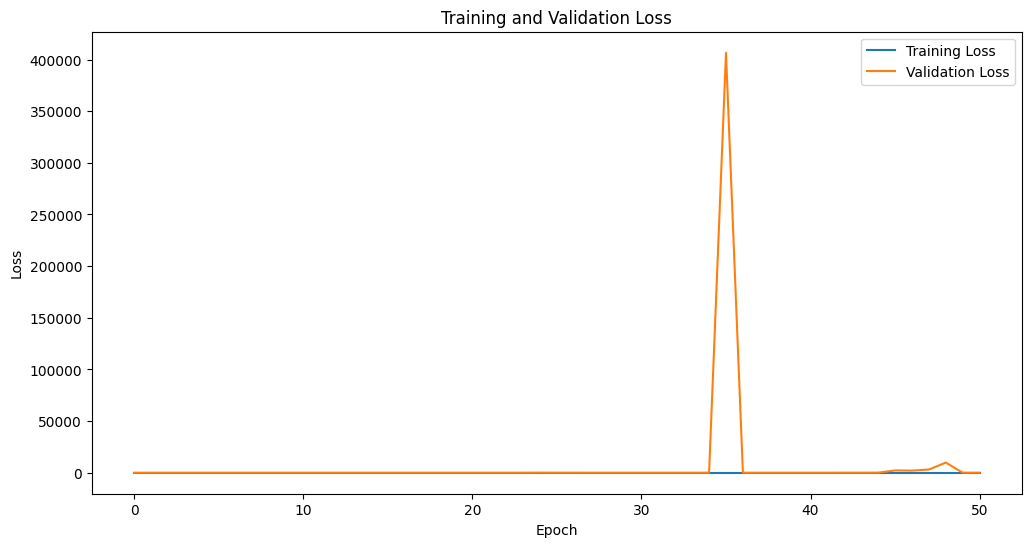

In [18]:
# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

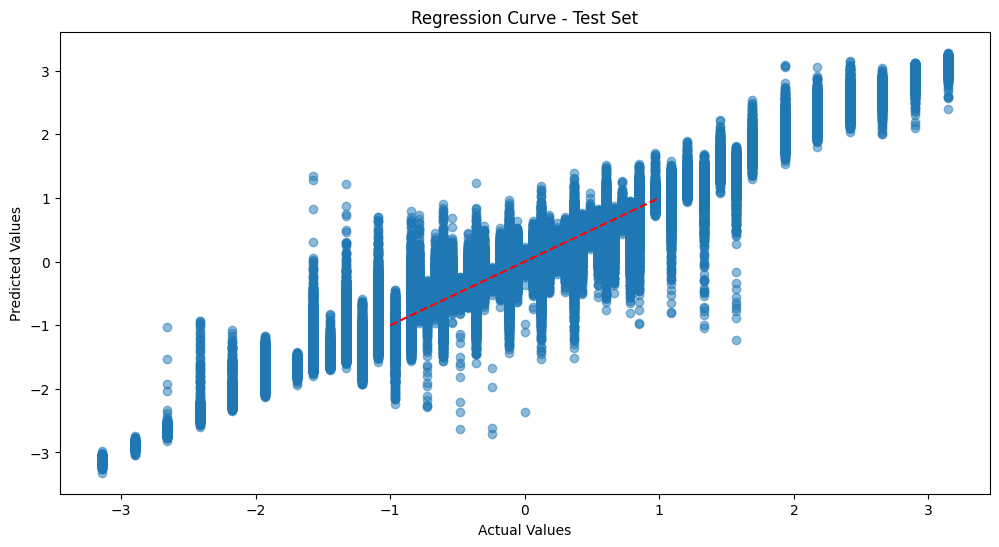

In [19]:
# Plot regression curve for test set
test_predictions = model.predict(X_test) * np.pi  # Use 'model' instead of 'best_model'
plt.figure(figsize=(12, 6))
plt.scatter(Y_test * np.pi, test_predictions, alpha=0.5)
plt.plot([-1, 1], [-1, 1], color='red', linestyle='--')
plt.title('Regression Curve - Test Set')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

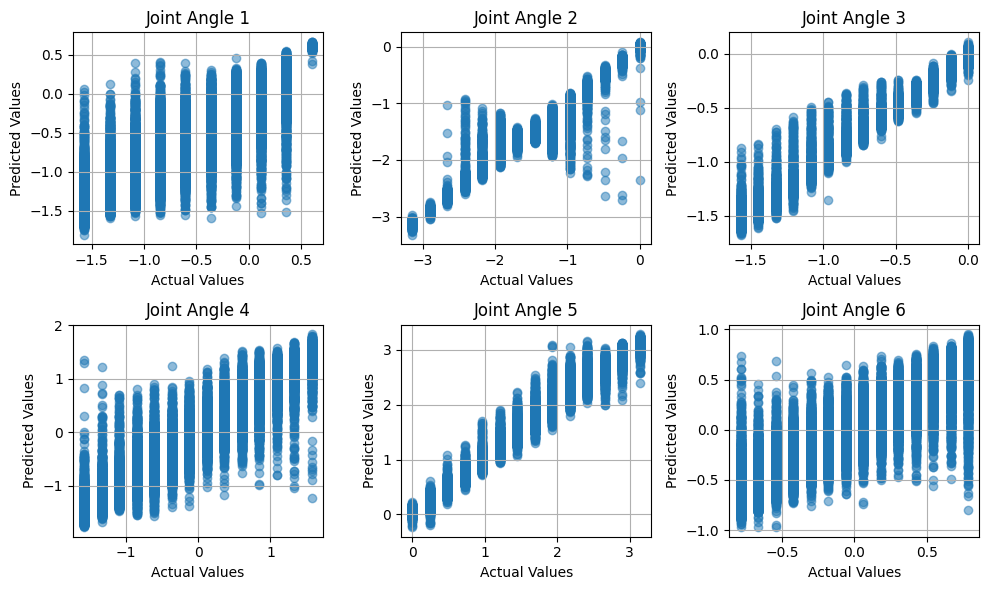

In [20]:
# Make predictions on the test set
predictions = model.predict(X_test)

# Inverse normalize the joint angles for better interpretation
predictions = predictions * np.pi
Y_test = Y_test * np.pi
# Plotting predicted vs. actual values
plt.figure(figsize=(10, 6))
for i in range(6):  # Assuming you have 6 joint angles
    plt.subplot(2, 3, i + 1)
    plt.scatter(Y_test[:, i], predictions[:, i], alpha=0.5)
    plt.title(f'Joint Angle {i + 1}')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)

plt.tight_layout()
plt.show()

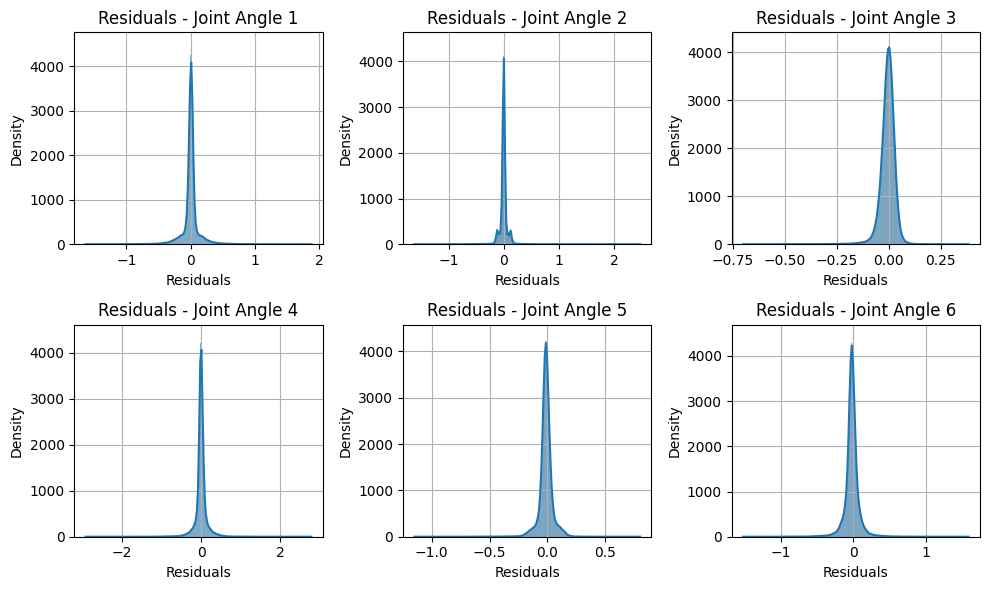

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
# Residual plots
residuals = Y_test - predictions

plt.figure(figsize=(10, 6))
for i in range(6):  # Assuming you have 6 joint angles
    plt.subplot(2, 3, i + 1)
    sns.histplot(residuals[:, i], kde=True)
    plt.title(f'Residuals - Joint Angle {i + 1}')
    plt.xlabel('Residuals')
    plt.ylabel('Density')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Load the best model for predictions
best_model = tf.keras.models.load_model("model_z2.h5")

# Test the loaded model with [10, 20, 30, 40, 50, 60]
test_inputs = np.array([[194.5, 161.4, 283.1, 0, -90, 38.07]])
predictions = best_model.predict(test_inputs) * np.pi

print("Predictions for test inputs:")
print(predictions)